<a href="https://colab.research.google.com/github/leo-aguiar/ibm_hr_analytics_employee/blob/main/IBM_Analytics_Employee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Bibliotecas para manipulação, visualização e ingestão de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub as kagg
import os

In [ ]:
# Realiza a ingestão do dataset diretamente do Kaggle para o ambiente local
path = kagg.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.


In [ ]:
# Carrega o dataset de rotatividade de funcionários em um DataFrame para posterior análise exploratória e modelagem
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv"))

In [ ]:
# Seleciona amostra aleatória de registros para inspeção inicial dos dados
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
420,29,No,Travel_Rarely,986,Research & Development,3,4,Medical,1,564,...,3,80,0,10,2,3,10,2,0,7
765,38,No,Travel_Frequently,1186,Research & Development,3,4,Other,1,1060,...,1,80,1,8,2,3,2,2,2,2
115,37,No,Travel_Rarely,1189,Sales,3,3,Life Sciences,1,152,...,1,80,0,12,3,3,5,3,1,3
1049,30,No,Travel_Rarely,1358,Sales,16,1,Life Sciences,1,1479,...,3,80,2,4,2,2,2,1,2,2
504,45,Yes,Travel_Frequently,306,Sales,26,4,Life Sciences,1,684,...,4,80,2,5,4,3,1,1,0,0


In [ ]:
# Inspeciona a estrutura geral do dataset para avaliar volume de registros, tipos de dados, completude das colunas e possíveis necessidades de pré-processamento
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# Avalia a completude do dataset ao consolidar, por coluna,
# a quantidade absoluta e percentual de valores ausentes por vaariável
missing_table = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(2)
})
missing_table = missing_table.sort_values(by='Missing %', ascending=False)
missing_table

,Missing Count,Missing %
Age,0,0.0
Attrition,0,0.0
BusinessTravel,0,0.0
DailyRate,0,0.0
Department,0,0.0
DistanceFromHome,0,0.0
Education,0,0.0
EducationField,0,0.0
EmployeeCount,0,0.0
EmployeeNumber,0,0.0


In [ ]:
# Annotation: Não foram identificados valores ausentes no dataset, indicando completude total das variáveis e eliminando a necessidade de tartamento de missinbg values nesta etapa do pré-processamento.

In [ ]:
# Segmenta as variáveis conforme seu tipo de dado para direcionar análises específicas de atributos numéricos e categóricos
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

In [ ]:
numerical_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [ ]:
categorical_cols

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

In [ ]:
# Variáveis categóricas ordinais codificadas numericamente
ordinal_cols = [
    'Education',
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'JobSatisfaction',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]

In [ ]:
# Exclui features ordinais da lista numérica por representarem categorias ordenadas, não valores contínuos
numerical_cols = [
    col for col in numerical_cols
    if col not in ordinal_cols
]

In [ ]:
numerical_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'EmployeeCount',
 'EmployeeNumber',
 'HourlyRate',
 'JobLevel',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [ ]:
# Analisa a distribuição da variável alvo para compreender a taxa de attrition e avaliar o balanceamento entre as classes do problema
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [ ]:
# Analisa a distribuição da variável alvo para compreender a taxa de attrition e avaliar o balanceamento entre as classes do problema
target_table = pd.DataFrame({
    'Contagem': df['Attrition'].value_counts(),
    'Taxa (%)': (df['Attrition'].value_counts(normalize=True) * 100).round(2)
})
target_table

,Contagem,Taxa (%)
Attrition,,
No,1233,83.88
Yes,237,16.12


In [ ]:
# Annotation: A variável alvo apresenta desbalanceamento moderado, com predominância da classe negativa, o que deverá ser considerado nas etapas de modelagem e avaliação de performance

In [ ]:
# Gera estatísticas descritivas das variáveis numéricas para avaliar distribuição, tendência central, dispersão e possíveis valores extremos
numerical_summary = df[numerical_cols].describe().T
numerical_summary

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.00,4919.0,8379.00,19999.0
MonthlyRate,1470.0,14313.103401,7117.786044,2094.0,8047.00,14235.5,20461.50,26999.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.00,2.0,4.00,9.0


In [ ]:
# Annotation: As colunas EmployeeCount e EmployeeCount não carregam informação útil para análise/modelagem, portanto podem ser removidas

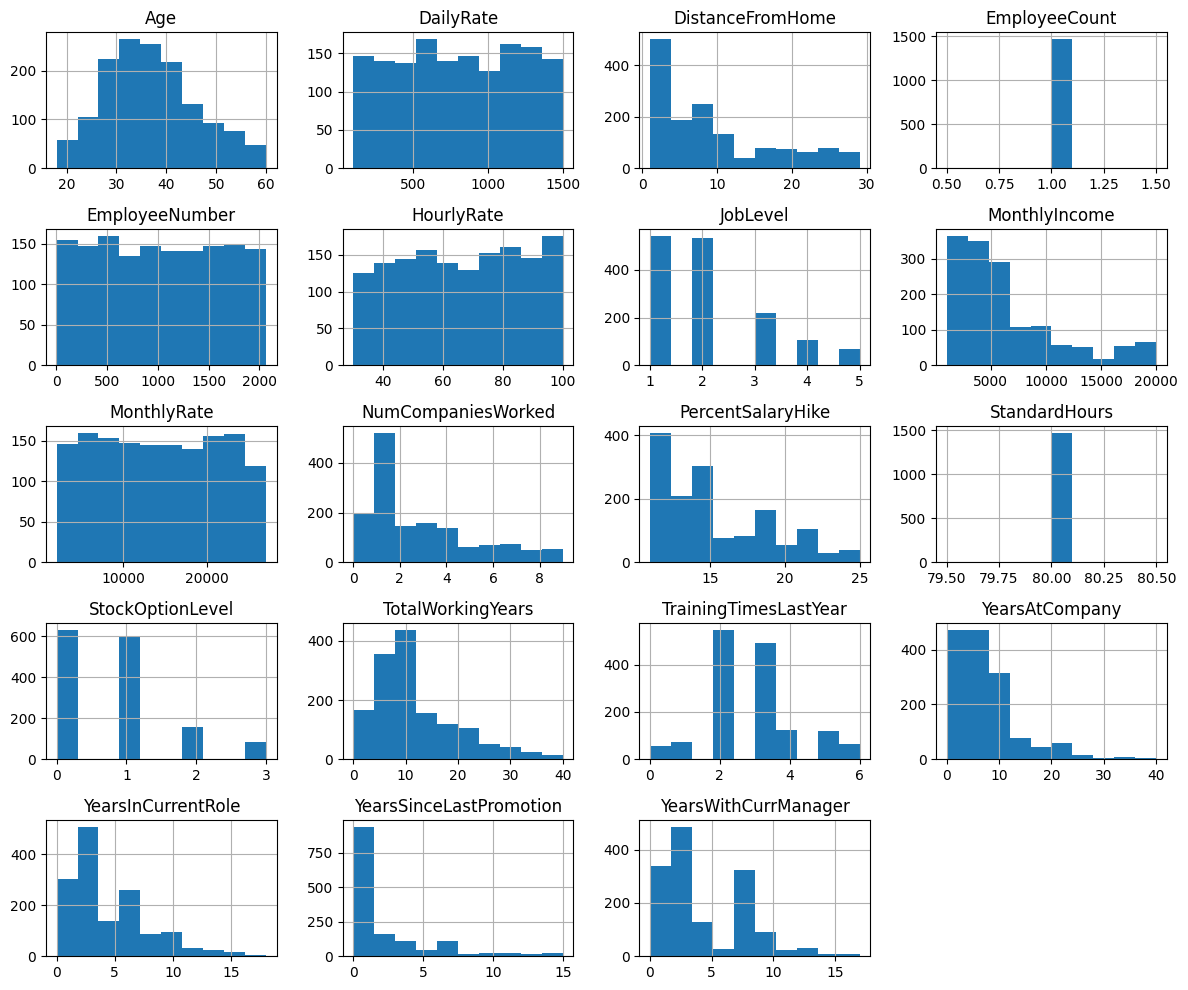

In [ ]:
# Visualiza a distribuição das variáveis numéricas para identificar padrões, assimetrias e possíveis valores extremos
df[numerical_cols].hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

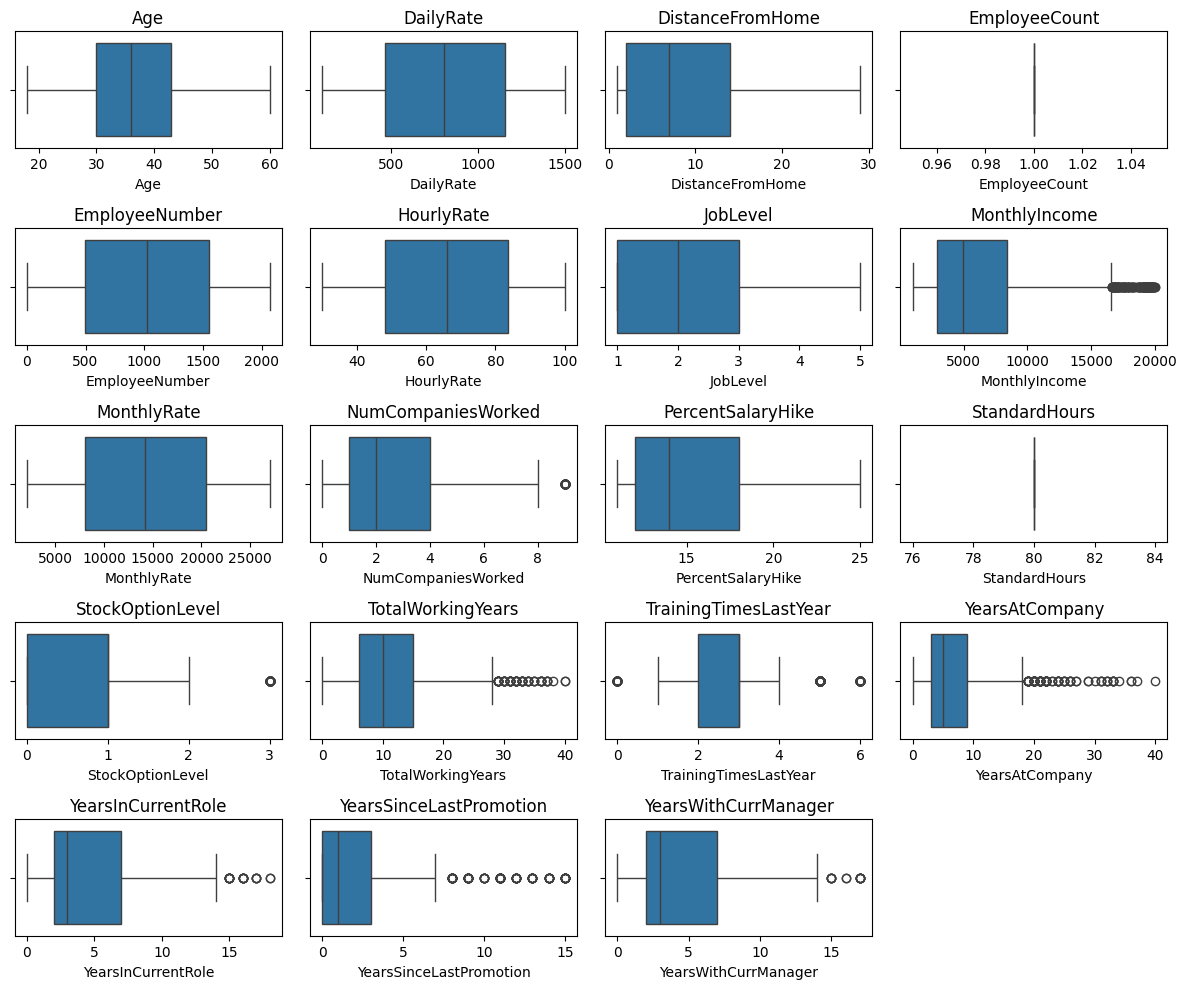

In [ ]:
# Analisa a dispersão das variáveis numéricas para identificar possíveis outliers e padrões de distribuição dos dados
plt.figure(figsize=(12, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Analisa a relação entre realização de horas extras e taxa de attrition para investigar possível impacto da carga de trabalho na rotatividade
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [ ]:
# Funcionários que realizam horas extras apresentam taxa de attrition significativamente superior aos que não realizam overtime (3x mais aproximadamente), sugerindo possível impacto da sobrecarga de trabalho na retenção.

In [ ]:
# Analisa a relação entre nível de satisfação no trabalho e taxa de attrition para investigar possível impacto da satisfação na retenção de funcionários
jobsat_attrition = pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100

jobsat_attrition

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


In [ ]:
# Observa-se uma relação inversa entre satisfação no trabalho e attrition, indicando que funcionários menos satisfeitos apresentam maiores taxas de saída da empresa

# A relação não é perfeitamente linear

In [ ]:
# Analisa a relação entre equilíbrio vida-trabalho e taxa de attrition para investigar possível impacto do bem-estar na retenção de funcionários

worklife_attrition = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
) * 100

worklife_attrition

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [ ]:
# Funcionários com pior equilíbrio entre vida pessoal e trabalho (nível 1) apresentam taxa de attrition significativamente superior aos demais grupos. Entretanto, não foi observada uma relação linear entre os níveis subsequentes da variável, sugerindo que o principal fator de risco está associado a percepções muito negativas de equilíbrio vida-trabalho.

In [ ]:
# Analisa a quantidade de funcionários em cada nível de WorkLifeBalance
df['WorkLifeBalance'].value_counts().sort_index()

,count
WorkLifeBalance,
1,80
2,344
3,893
4,153


In [ ]:
# Há evidências de que funcionários com pior equilíbrio entre vida pessoal e trabalho apresentam maior propensão à saída da empresa.

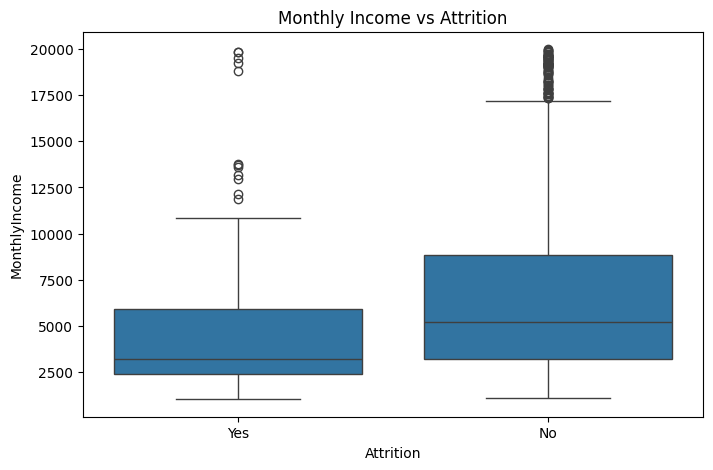

In [ ]:
# Compara a distribuição salarial entre funcionários que permaneceram e os que deixaram a empresa para investigar possível relação entre renda e attrition
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.title('Monthly Income vs Attrition')
plt.show()

In [ ]:
# Os funcionários que permaneceram na empresa apresentam renda mensal superior aos que deixaram a organização. A mediana salarial do grupo sem attrition é significativamente maior, sugerindo uma associação entre remuneração e retenção de talentos.

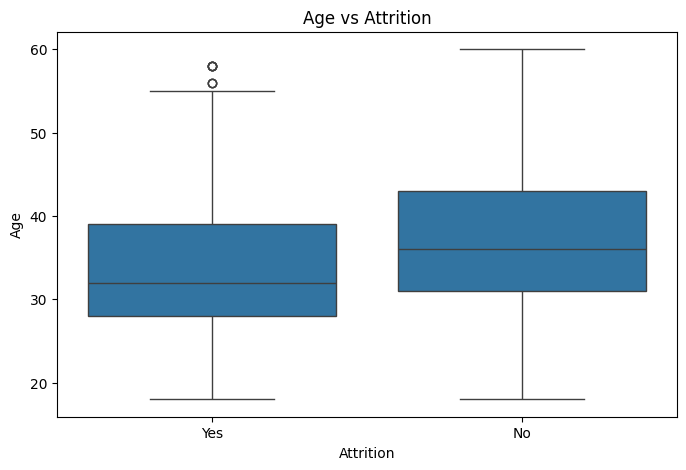

In [ ]:
# Compara a distribuição de idade entre funcionários que permaneceram e os que deixaram a empresa para investigar possível relação entre faixa etária e attrition
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Attrition',
    y='Age',
    data=df
)

plt.title('Age vs Attrition')
plt.show()

In [ ]:
# Funcionários que deixaram a empresa apresentam idade inferior aos que permaneceram. A distribuição etária do grupo com attrition encontra-se deslocada para faixas mais jovens, sugerindo associação entre menor idade e maior propensão à saída da organização.

In [ ]:
# Verifica a distribuição da variável Over18 para avaliar sua variabilidade e relevância analítica
df['Over18'].value_counts()

,count
Over18,
Y,1470


In [ ]:
# A variável Over18 apresenta apenas uma categoria (Y) em todos os registros, não contribuindo para a discriminação entre observações e sendo candidata à remoção em etapas posteriores de preparação dos dados.

In [ ]:
categorical_cols = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'OverTime'
]

In [ ]:
results = []

In [ ]:
# Analisa a taxa de attrition para cada categoria das variáveis categóricas, permitindo identificar grupos com maior ou menor propensão à saída da empresa
for col in categorical_cols:

    print(f'\n{"="*50}')
    print(f'Variável: {col}')
    print(f'{"="*50}')

    display(
        pd.crosstab(
            df[col],
            df['Attrition'],
            normalize='index'
        ) * 100
    )


Variável: BusinessTravel


Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855



Variável: Department


Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803



Variável: EducationField


...

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036



Variável: MaritalStatus


Attrition,No,Yes
MaritalStatus,,
Divorced,89.908257,10.091743
Married,87.518574,12.481426
Single,74.468085,25.531915



Variável: OverTime


Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [ ]:
# A análise exploratória indica que OverTime, JobRole, MaritalStatus e BusinessTravel apresentam os maiores contrastes nas taxas de attrition, sugerindo forte potencial preditivo. Por outro lado, variáveis como Gender demonstram diferenças reduzidas entre categorias, indicando menor relevância para explicar a rotatividade de funcionários.

In [ ]:
# Converte a variável alvo para formato numérico, permitindo análises estatísticas e cálculo de correlação
df['Attrition_Num'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

In [ ]:
# Seleciona as variáveis numéricas juntamente com a variável alvo para análise de correlação
corr_df = df[numerical_cols + ['Attrition_Num']]

In [ ]:
corr_df.head()

,Age,DailyRate,DistanceFromHome,EmployeeCount,EmployeeNumber,HourlyRate,JobLevel,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Num
0,41,1102,1,1,1,94,2,5993,19479,8,11,80,0,8,0,6,4,0,5,1
1,49,279,8,1,2,61,2,5130,24907,1,23,80,1,10,3,10,7,1,7,0
2,37,1373,2,1,4,92,1,2090,2396,6,15,80,0,7,3,0,0,0,0,1
3,33,1392,3,1,5,56,1,2909,23159,1,11,80,0,8,3,8,7,3,0,0
4,27,591,2,1,7,40,1,3468,16632,9,12,80,1,6,3,2,2,2,2,0


In [ ]:
# Calcula a matriz de correlação entre as variáveis numéricas e a variável alvo para identificar possíveis relações lineares
corr_matrix = corr_df.corr()

In [ ]:
# Ordena as correlações das variáveis numéricas em relação ao target para identificar os fatores mais associados ao attrition
corr_matrix['Attrition_Num'].sort_values(ascending=False)

,Attrition_Num
Attrition_Num,1.000000
DistanceFromHome,0.077924
NumCompaniesWorked,0.043494
MonthlyRate,0.015170
HourlyRate,-0.006846
EmployeeNumber,-0.010577
PercentSalaryHike,-0.013478
YearsSinceLastPromotion,-0.033019
DailyRate,-0.056652
TrainingTimesLastYear,-0.059478


In [ ]:
# Remove variáveis constantes da análise de correlação, pois não apresentam variabilidade e geram correlações indefinidas
corr_df = corr_df.drop(
    columns=['EmployeeCount', 'StandardHours']
)

In [ ]:
# Recalcula a matriz de correlação após remover variáveis constantes
corr_matrix = corr_df.corr()

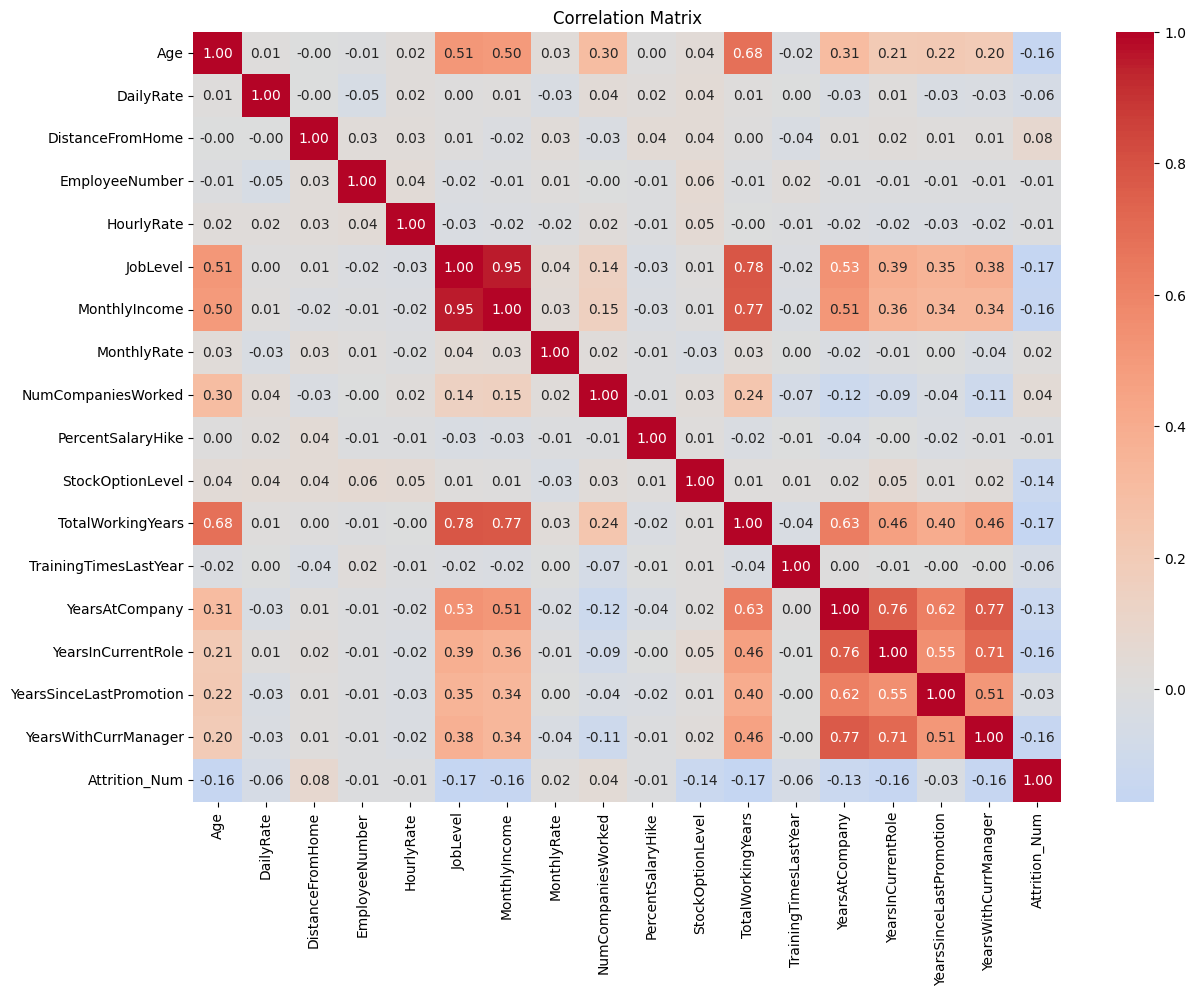

In [ ]:
# Exibe a matriz de correlação entre as variáveis numéricas para identificar relações lineares e possíveis casos de multicolinearidade
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Verifica quantas linhas duplicadas existem no DataFrame
duplicated_lines = df.duplicated().sum()

print(f'Quantidade de linhas duplicadas: {duplicated_lines}')

Quantidade de linhas duplicadas: 0


In [ ]:
# Verifica a quantidade de identificadores de funcionários duplicados
duplicated_employee_ids = df['EmployeeNumber'].duplicated().sum()

print(f'Quantidade de EmployeeNumber duplicados: {duplicated_employee_ids}')

Quantidade de EmployeeNumber duplicados: 0


In [ ]:
# Remove a coluna identificadora dos funcionários, pois ela não possui valor preditivo para o modelo
df = df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'])

In [ ]:
# Separa as variáveis explicativas (features), removendo a variável alvo
X = df.drop(columns=['Attrition', 'Attrition_Num'])

# Separa a variável alvo (target), que será prevista pelo modelo
y = df['Attrition']

In [ ]:
# Importa a função responsável por dividir o conjunto de dados em treino e teste
from sklearn.model_selection import train_test_split

In [ ]:
# Divide os dados em conjuntos de treino e teste, preservando a proporção das classes da variável alvo
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Verifica as dimensões do conjunto de treino das variáveis explicativas
X_train.shape

(1176, 30)

In [ ]:
# Verifica as dimensões do conjunto de teste das variáveis explicativas
X_test.shape

(294, 30)

In [ ]:
# Verifica as dimensões do conjunto de treino da variável alvo
y_train.shape

(1176,)

In [ ]:
# Verifica as dimensões do conjunto de teste da variável alvo
y_test.shape

(294,)

In [ ]:
# Verifica a distribuição percentual das classes no conjunto de treino
display(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Verifica a distribuição percentual das classes no conjunto de teste
display(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

,proportion
Attrition,
No,83.84
Yes,16.16


,proportion
Attrition,
No,84.01
Yes,15.99


In [ ]:
# Annotation: Constrói o pipeline de pré-processamento responsável por preparar as variáveis para o treinamento do modelo, aplicando transformações específicas para atributos numéricos e categóricos de forma consistente e sem risco de data leakage.

In [ ]:
# Importa o codificador para transformar variáveis categóricas em representações numéricas e o transformador responsável por padronizar as variáveis numéricas
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

# Importa o transformador responsável por aplicar diferentes pré-processamentos em grupos de colunas
from sklearn.compose import ColumnTransformer

# Importa a classe utilizada para construir pipelines de pré-processamento e modelagem
from sklearn.pipeline import Pipeline

# Importa o algoritmo de Regressão Logística
from sklearn.linear_model import LogisticRegression

# Importa o transformador responsável por padronizar as variáveis numéricas
from sklearn.preprocessing import StandardScaler

In [ ]:
# Identifica automaticamente as variáveis numéricas presentes no conjunto de treino
numerical_features = X_train.select_dtypes(include='number').columns.tolist()

# Identifica automaticamente as variáveis categóricas presentes no conjunto de treino
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

In [ ]:
# Exibe a quantidade de variáveis numéricas utilizadas pelo modelo
print(f'Variáveis numéricas: {len(numerical_features)}')

# Exibe a quantidade de variáveis categóricas utilizadas pelo modelo
print(f'Variáveis categóricas: {len(categorical_features)}')

Variáveis numéricas: 23
Variáveis categóricas: 7


In [ ]:
# Configura o pré-processamento das variáveis, aplicando transformações
# específicas para cada tipo de atributo
preprocessor = ColumnTransformer(

    transformers=[

        # Padroniza as variáveis numéricas para que possuam média 0 e desvio padrão 1
        (
            'num',
            StandardScaler(),
            numerical_features
        ),

        # Aplica One-Hot Encoding às variáveis categóricas
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )

    ]
)

In [ ]:
# Constrói o pipeline de Machine Learning integrando as etapas de
# pré-processamento dos dados e treinamento da Regressão Logística
pipeline = Pipeline(

    steps=[

        # Aplica o pré-processamento das variáveis
        ('preprocessor', preprocessor),

        # Treina o modelo de Regressão Logística
        ('model', LogisticRegression(random_state=42))

    ]

)

In [ ]:
# Treina o pipeline utilizando o conjunto de treino
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOptionLevel',
                                                   'TotalWorkingYears',
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('model', LogisticRegression(random_state=42))])

In [ ]:
# Gera as previsões do modelo para o conjunto de teste
y_pred = pipeline.predict(X_test)